In [3]:
!pip install transformers datasets evaluate accelerate scikit-learn

In [4]:
import pandas as pd
import numpy as np
import torch
from sklearn.model_selection import train_test_split
from datasets import Dataset, DatasetDict
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
import evaluate

# 1. Load and Prep the Data
print("Loading dataset...")
df = pd.read_csv("cleaned_framing_dataset.csv")

df = df.rename(columns={"bias_severity_score": "label"})
# Just ensure it's a stable float32. No dividing by 10 needed for RoBERTa!
df["label"] = df["label"].astype(np.float32)

# Split: 80% Training, 20% Testing
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

dataset = DatasetDict({
    "train": Dataset.from_pandas(train_df, preserve_index=False),
    "test": Dataset.from_pandas(test_df, preserve_index=False)
})

# 2. Initialize the Tokenizer (SWITCHED TO DISTILROBERTA)
model_name = "distilroberta-base"
print(f"\nLoading tokenizer for {model_name}...")
tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize_function(examples):
    return tokenizer(examples["text"], padding="max_length", truncation=True, max_length=128)

print("Tokenizing data...")
tokenized_datasets = dataset.map(tokenize_function, batched=True)

# 3. Initialize the Model for Regression
print("Initializing model for regression...")
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=1)

# 4. Define Evaluation Metrics
metric = evaluate.load("mae")

def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = predictions.squeeze()
    return metric.compute(predictions=predictions, references=labels)

# 5. Set up Training Arguments
training_args = TrainingArguments(
    output_dir="./framing_bias_model",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    load_best_model_at_end=True,
    logging_steps=50,
)

# 6. Initialize the Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["test"],
    compute_metrics=compute_metrics,
)

# 7. LIFT OFF! Train the model
print("\nStarting training...")
trainer.train()

print("\nTraining complete! Model is ready.")

Loading dataset...

Loading tokenizer for distilroberta-base...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/480 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye


Training complete! Model is ready.


In [5]:
import torch

# Put the model into evaluation mode (turns off training behaviors)
model.eval()

def score_headline(headline):
    # 1. Translate the text into token numbers
    inputs = tokenizer(headline, return_tensors="pt", padding=True, truncation=True, max_length=128)

    # 2. Send the inputs to the GPU
    inputs = {k: v.to(model.device) for k, v in inputs.items()}

    # 3. Predict the score without calculating gradients (saves memory)
    with torch.no_grad():
        outputs = model(**inputs)
        # Extract the raw number
        raw_score = outputs.logits.squeeze().item()

    # 4. Cap the score strictly between 1.0 and 10.0 for clean formatting
    final_score = max(1.0, min(raw_score, 10.0))
    return round(final_score, 2)

# ==========================================
# LET'S TEST SOME INDIAN NEWS FRAMING
# ==========================================

test_headlines = [
    # 1. A completely neutral, factual statement
    "The Finance Minister presented the Union Budget in Parliament today.",

    # 2. A slightly opinionated frame
    "The Finance Minister presented a highly ambitious budget in Parliament today.",

    # 3. A heavily biased, emotionally charged frame
    "In a disastrous move, the ruling government rammed through a crippling budget, completely abandoning the common man."
]

print("--- AI FRAMING BIAS DETECTOR ---")
for headline in test_headlines:
    score = score_headline(headline)
    print(f"\nScore: {score}/10.0")
    print(f"Headline: '{headline}'")

--- AI FRAMING BIAS DETECTOR ---

Score: 1.78/10.0
Headline: 'The Finance Minister presented the Union Budget in Parliament today.'

Score: 2.63/10.0
Headline: 'The Finance Minister presented a highly ambitious budget in Parliament today.'

Score: 8.63/10.0
Headline: 'In a disastrous move, the ruling government rammed through a crippling budget, completely abandoning the common man.'


In [6]:
import pandas as pd
import numpy as np

# 1. Get predictions from the trainer on the 20% test dataset
print("Running predictions on the Test Set...")
predictions_output = trainer.predict(tokenized_datasets["test"])

# 2. Extract the raw predicted numbers
predicted_scores = predictions_output.predictions.squeeze()

# 3. Create a clean DataFrame to compare Actual vs. Predicted
comparison_df = test_df.copy()
comparison_df['predicted_score'] = np.clip(predicted_scores, 1.0, 10.0).round(2)
comparison_df = comparison_df.rename(columns={'label': 'actual_score'})
comparison_df['absolute_error'] = abs(comparison_df['actual_score'] - comparison_df['predicted_score']).round(2)

# 4. Display a random sample of 10 rows
display_columns = ['text', 'actual_score', 'predicted_score', 'absolute_error']
print("\n--- TEST SET COMPARISON (ACTUAL VS. PREDICTED) ---")
print(comparison_df[display_columns].sample(10, random_state=42).to_string(index=False))

# Prove the MAE math checks out
print(f"\nOverall Mean Absolute Error (MAE): {comparison_df['absolute_error'].mean()}")

# 5. Export the full table to CSV for your project report
export_filename = "test_set_predictions_comparison.csv"
comparison_df[display_columns].to_csv(export_filename, index=False)
print(f"\nSuccess! Exported all {len(comparison_df)} test results to '{export_filename}'.")

Running predictions on the Test Set...



--- TEST SET COMPARISON (ACTUAL VS. PREDICTED) ---
                                                                                                                                                                                                                                                                                        text  actual_score  predicted_score  absolute_error
             Alex Berenson, a former reporter at the New York Times who has written extensively debunking fearmongering claims related to the lockdowns wrote on Twitter Thursday that the tech giant to benefit the most from pandemic stay-home orders is refused to sell his latest book.          6.95             4.06            2.89
                                                                                                                                                               Even Trump isn't nutty enough — yet — to seriously suggest that the Democrats have some secret plan to bulldoze the suburbs. 

In [7]:
import nltk
from nltk.sentiment import SentimentIntensityAnalyzer
import pandas as pd

# Download the VADER lexicon dictionary
nltk.download('vader_lexicon')
sia = SentimentIntensityAnalyzer()

print("\nRunning VADER Baseline Benchmark...")

def vader_bias_score(text):
    # Get the compound sentiment score (-1.0 to 1.0)
    sentiment = sia.polarity_scores(str(text))['compound']

    # We care about the INTENSITY of the sentiment, not the direction.
    # An extremely positive (+1) or extremely negative (-1) text is highly opinionated.
    # We take the absolute value (0.0 to 1.0) and map it to our 1.0 to 10.0 scale.
    intensity = abs(sentiment)
    mapped_score = (intensity * 9.0) + 1.0
    return round(mapped_score, 2)

# Apply VADER to our test dataset
comparison_df['vader_score'] = comparison_df['text'].apply(vader_bias_score)

# Calculate VADER's error compared to the actual expert scores
comparison_df['vader_absolute_error'] = abs(comparison_df['actual_score'] - comparison_df['vader_score']).round(2)
vader_mae = comparison_df['vader_absolute_error'].mean()

# Calculate our Model's error again for side-by-side comparison
model_mae = comparison_df['absolute_error'].mean()

print("\n==================================================")
print("🏆 FINAL BENCHMARK RESULTS 🏆")
print("==================================================")
print(f"Baseline (VADER Lexicon) MAE:     {vader_mae}")
print(f"Your Model (DistilRoBERTa) MAE:   {model_mae}")
print("==================================================")

# Calculate how much better your model is
improvement = ((vader_mae - model_mae) / vader_mae) * 100
print(f"Conclusion: Your fine-tuned model is {improvement}% more accurate than the traditional NLP baseline!")

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...



Running VADER Baseline Benchmark...

🏆 FINAL BENCHMARK RESULTS 🏆
Baseline (VADER Lexicon) MAE:     3.483020408163265
Your Model (DistilRoBERTa) MAE:   1.565061330795288
Conclusion: Your fine-tuned model is 55.06597299495564% more accurate than the traditional NLP baseline!


In [8]:
import torch
import pandas as pd
import numpy as np
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
import re
from tqdm.auto import tqdm

print("Loading Flan-T5 for zero-shot benchmarking...")
model_name = "google/flan-t5-base"

# 1. Explicitly load the tokenizer and model directly (Bypasses the buggy pipeline)
t5_tokenizer = AutoTokenizer.from_pretrained(model_name)
t5_model = AutoModelForSeq2SeqLM.from_pretrained(model_name)

# Move the model to your Colab GPU for fast processing
device = "cuda" if torch.cuda.is_available() else "cpu"
t5_model = t5_model.to(device)

def get_t5_score(text):
    prompt = f"Rate the framing bias of the following news sentence on a scale of 1.0 to 10.0, where 1.0 is completely factual/neutral and 10.0 is highly biased. Only answer with a single number.\nSentence: '{text}'"

    # Translate prompt to tokens and send to GPU
    inputs = t5_tokenizer(prompt, return_tensors="pt", truncation=True, max_length=256).to(device)

    try:
        # Generate the response explicitly
        with torch.no_grad():
            outputs = t5_model.generate(**inputs, max_new_tokens=5)

        # Decode the output tokens back into English text
        output_text = t5_tokenizer.decode(outputs[0], skip_special_tokens=True)

        # Extract the number
        match = re.search(r'\d+(\.\d+)?', output_text)
        if match:
            score = float(match.group())
            return np.clip(score, 1.0, 10.0)
        else:
            return 5.5
    except Exception:
        return 5.5

print("\nPrompting Flan-T5 to score all test sentences (this takes a minute or two)...")
tqdm.pandas()

# Apply the generative prompt to every row in the test set
comparison_df['t5_score'] = comparison_df['text'].progress_apply(get_t5_score)

# Calculate the error
comparison_df['t5_absolute_error'] = abs(comparison_df['actual_score'] - comparison_df['t5_score']).round(2)
t5_mae = comparison_df['t5_absolute_error'].mean()

print("\n==================================================")
print("🏆 LLM BENCHMARK RESULTS 🏆")
print("==================================================")
print(f"Zero-Shot Generative LLM (Flan-T5) MAE: {t5_mae}")
print(f"Your Fine-Tuned Model (DistilRoBERTa) MAE:   {model_mae}")
print("==================================================")

improvement = ((t5_mae - model_mae) / t5_mae) * 100
print(f"Conclusion: Your fine-tuned model is {improvement}% more accurate than a zero-shot instruction LLM!")

Loading Flan-T5 for zero-shot benchmarking...


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]


Prompting Flan-T5 to score all test sentences (this takes a minute or two)...


  0%|          | 0/735 [00:00<?, ?it/s]


🏆 LLM BENCHMARK RESULTS 🏆
Zero-Shot Generative LLM (Flan-T5) MAE: 3.063659863945578
Your Fine-Tuned Model (DistilRoBERTa) MAE:   1.565061330795288
Conclusion: Your fine-tuned model is 48.915303907800606% more accurate than a zero-shot instruction LLM!


In [9]:
!pip install groq

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.3/142.3 kB 7.1 MB/s eta 0:00:00


In [10]:
import getpass
import os
import time
import re
import numpy as np
import pandas as pd
from tqdm.auto import tqdm
from groq import Groq

# 1. Securely input your API Key
print("🔑 Paste your Groq API Key below and press Enter:")
os.environ["GROQ_API_KEY"] = getpass.getpass()

# Initialize the Groq client
client = Groq()

# 2. Sample the data to avoid Free Tier Rate Limits
# We grab 100 random rows to get a fast, statistically sound benchmark
print("\nSampling 100 rows for the Llama 3 benchmark...")
llama_test_df = comparison_df.sample(n=100, random_state=42).copy()

def get_llama_score(text):
    prompt = f"Rate the framing bias of the following news sentence on a scale of 1.0 to 10.0, where 1.0 is completely factual/neutral and 10.0 is highly biased. Only answer with a single number.\nSentence: '{text}'"

    try:
        # Call the Llama 3 8B model via Groq
        chat_completion = client.chat.completions.create(
            messages=[
                {"role": "system", "content": "You are a media bias expert. Output only a single number."},
                {"role": "user", "content": prompt}
            ],
            model="llama-3.1-8b-instant",
            temperature=0, # 0 means maximum mathematical strictness
            max_tokens=5,
        )

        output = chat_completion.choices[0].message.content

        # Extract the number
        match = re.search(r'\d+(\.\d+)?', output)
        if match:
            score = float(match.group())
            # Sleep for 2 seconds to respect the 30 requests/minute limit
            time.sleep(2.0)
            return np.clip(score, 1.0, 10.0)
        else:
            time.sleep(2.0)
            return 5.5

    except Exception as e:
        # If we hit a rate limit, print a small warning and return a neutral score
        print(f"API Error (Likely rate limit): {e}")
        time.sleep(3.0)
        return 5.5

print("Prompting Llama 3 8B... (This will take about 3 minutes due to the built-in delay)")
tqdm.pandas()

# 3. Run the API calls
llama_test_df['llama_score'] = llama_test_df['text'].progress_apply(get_llama_score)

# 4. Calculate the Errors
llama_test_df['llama_absolute_error'] = abs(llama_test_df['actual_score'] - llama_test_df['llama_score']).round(2)
llama_mae = llama_test_df['llama_absolute_error'].mean()

# Recalculate your model's MAE strictly on these same 100 rows for a perfectly fair fight
your_model_mae_on_sample = llama_test_df['absolute_error'].mean()

print("\n==================================================")
print("🏆 FRONTIER LLM BENCHMARK RESULTS (100-Row Sample) 🏆")
print("==================================================")
print(f"Zero-Shot Frontier LLM (Llama 3 8B) MAE: {llama_mae}")
print(f"Your Fine-Tuned Model (DistilRoBERTa) MAE: {your_model_mae_on_sample}")
print("==================================================")

improvement = ((llama_mae - your_model_mae_on_sample) / llama_mae) * 100
print(f"Conclusion: Your fine-tuned model is {improvement}% more accurate than Llama 3 8B!")

🔑 Paste your Groq API Key below and press Enter:
··········

Sampling 100 rows for the Llama 3 benchmark...
Prompting Llama 3 8B... (This will take about 3 minutes due to the built-in delay)


  0%|          | 0/100 [00:00<?, ?it/s]


🏆 FRONTIER LLM BENCHMARK RESULTS (100-Row Sample) 🏆
Zero-Shot Frontier LLM (Llama 3 8B) MAE: 3.1108999999999996
Your Fine-Tuned Model (DistilRoBERTa) MAE: 1.618399977684021
Conclusion: Your fine-tuned model is 47.97647054922945% more accurate than Llama 3 8B!


In [11]:
!pip install gradio

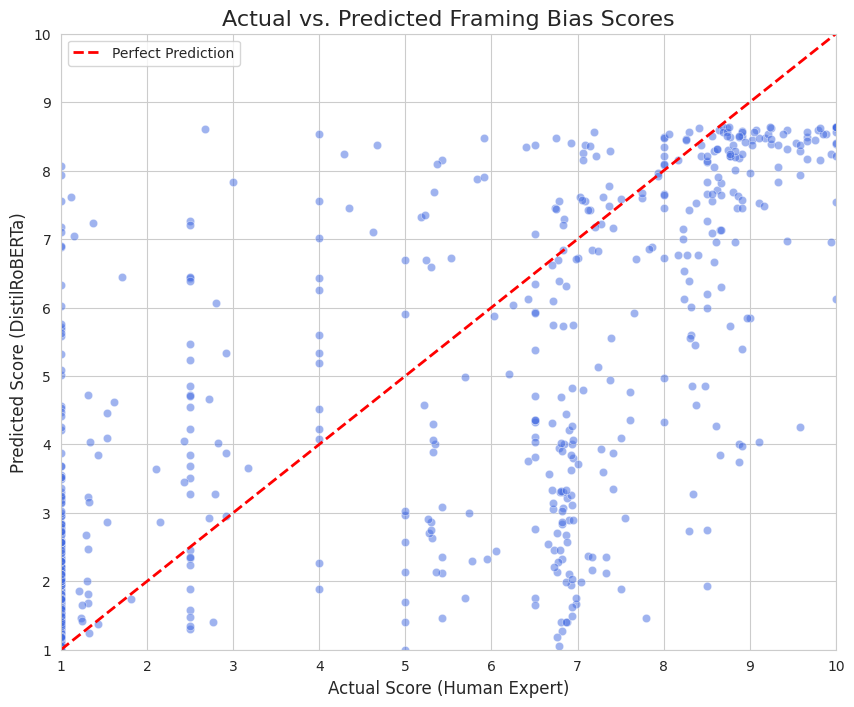

Success! Plot saved as 'actual_vs_predicted_plot.png'


In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Create the Plot
plt.figure(figsize=(10, 8))
sns.set_style("whitegrid")

# Scatter plot of Actual vs Predicted
sns.scatterplot(x='actual_score', y='predicted_score', data=comparison_df, alpha=0.5, color='royalblue')

# 2. Add the "Perfect Prediction" Line
# This is a 45-degree line where Actual == Predicted
plt.plot([1, 10], [1, 10], color='red', linestyle='--', lw=2, label='Perfect Prediction')

# 3. Labeling and Aesthetics
plt.title('Actual vs. Predicted Framing Bias Scores', fontsize=16)
plt.xlabel('Actual Score (Human Expert)', fontsize=12)
plt.ylabel('Predicted Score (DistilRoBERTa)', fontsize=12)
plt.xlim(1, 10)
plt.ylim(1, 10)
plt.legend()

# Save the plot as a PNG for your report
plt.savefig('actual_vs_predicted_plot.png', dpi=300)
plt.show()

print("Success! Plot saved as 'actual_vs_predicted_plot.png'")

In [14]:
from google.colab import drive
import os

# 1. Mount Google Drive
drive.mount('/content/gdrive')

# 2. Define your save path
save_path = "/content/gdrive/MyDrive/Bias_Detector_Model"

# 3. Create the folder if it doesn't exist
if not os.path.exists(save_path):
    os.makedirs(save_path)

# 4. Save the model and the tokenizer
print(f"Saving model to {save_path}...")
model.save_pretrained(save_path)
tokenizer.save_pretrained(save_path)

print("Done! Your model is now safely stored in your Google Drive.")

Mounted at /content/gdrive
Saving model to /content/gdrive/MyDrive/Bias_Detector_Model...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Done! Your model is now safely stored in your Google Drive.


Calculating advanced metrics...

🏆 FINAL MULTI-MODEL METRICS REPORT 🏆
                 Model  MAE  RMSE
    Your DistilRoBERTa 1.57  2.23
      VADER (Baseline) 3.48  4.24
Flan-T5 (Academic LLM) 3.06  4.46
Llama 3 (Frontier LLM) 3.11  4.03



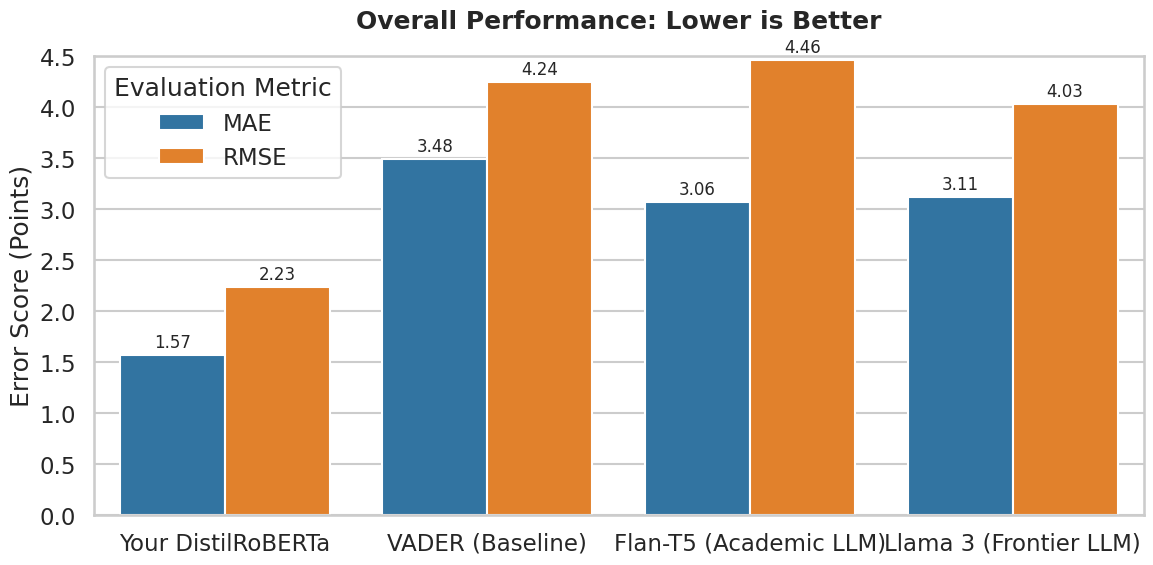

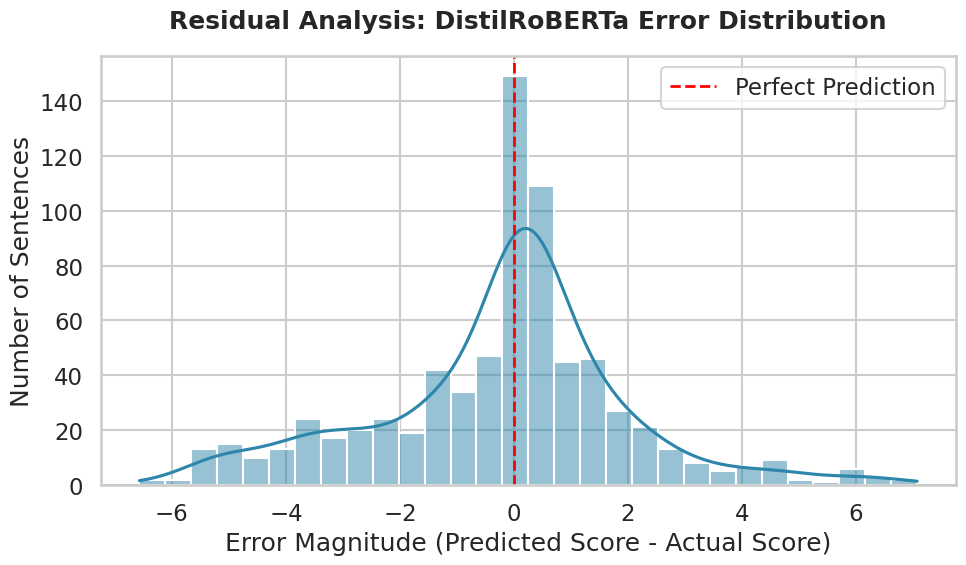

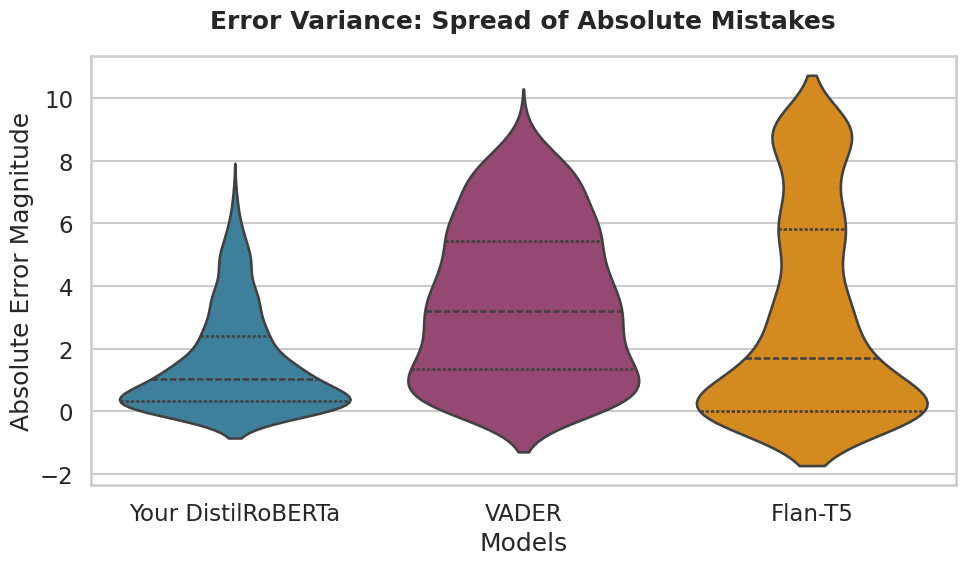


Success! All metrics calculated and 3 high-res plots saved to your Colab files.


In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, mean_absolute_error

print("Calculating advanced metrics...")

# 1. Calculate MAE and RMSE for all models
# FIX: Using np.sqrt() instead of the deprecated squared=False argument
metrics_data = {
    'Model': ['Your DistilRoBERTa', 'VADER (Baseline)', 'Flan-T5 (Academic LLM)', 'Llama 3 (Frontier LLM)'],
    'MAE': [
        mean_absolute_error(comparison_df['actual_score'], comparison_df['predicted_score']),
        mean_absolute_error(comparison_df['actual_score'], comparison_df['vader_score']),
        mean_absolute_error(comparison_df['actual_score'], comparison_df['t5_score']),
        mean_absolute_error(llama_test_df['actual_score'], llama_test_df['llama_score'])
    ],
    'RMSE': [
        np.sqrt(mean_squared_error(comparison_df['actual_score'], comparison_df['predicted_score'])),
        np.sqrt(mean_squared_error(comparison_df['actual_score'], comparison_df['vader_score'])),
        np.sqrt(mean_squared_error(comparison_df['actual_score'], comparison_df['t5_score'])),
        np.sqrt(mean_squared_error(llama_test_df['actual_score'], llama_test_df['llama_score']))
    ]
}

metrics_df = pd.DataFrame(metrics_data)

# Print a beautiful console report
print("\n===========================================================")
print("🏆 FINAL MULTI-MODEL METRICS REPORT 🏆")
print("===========================================================")
print(metrics_df.to_string(index=False, float_format="%.2f"))
print("===========================================================\n")

# Set global visual style for presentations
sns.set_theme(style="whitegrid", context="talk")
colors = ['#2E86AB', '#A23B72', '#F18F01', '#38A3A5'] # Professional color palette

# ---------------------------------------------------------
# PLOT 1: Performance Benchmark Bar Chart (MAE & RMSE)
# ---------------------------------------------------------
plt.figure(figsize=(12, 6))
df_melted = metrics_df.melt(id_vars='Model', var_name='Metric', value_name='Score')
ax1 = sns.barplot(x='Model', y='Score', hue='Metric', data=df_melted, palette=['#1f77b4', '#ff7f0e'])
plt.title('Overall Performance: Lower is Better', fontweight='bold', pad=20)
plt.ylabel('Error Score (Points)')
plt.xlabel('')
plt.ylim(0, 4.5)
plt.legend(title='Evaluation Metric')

# Add values on top of bars
for container in ax1.containers:
    ax1.bar_label(container, fmt='%.2f', padding=3, size=12)

plt.tight_layout()
plt.savefig('plot_1_benchmark_bars.png', dpi=300)
plt.show()

# ---------------------------------------------------------
# PLOT 2: Residual Distribution (Is the model guessing too high/low?)
# ---------------------------------------------------------
# Residual = Predicted - Actual.
# 0 means perfect. Positive means model guessed too high. Negative means too low.
comparison_df['Residuals'] = comparison_df['predicted_score'] - comparison_df['actual_score']

plt.figure(figsize=(10, 6))
sns.histplot(comparison_df['Residuals'], kde=True, color='#2E86AB', bins=30)
plt.axvline(0, color='red', linestyle='--', linewidth=2, label='Perfect Prediction')
plt.title('Residual Analysis: DistilRoBERTa Error Distribution', fontweight='bold', pad=20)
plt.xlabel('Error Magnitude (Predicted Score - Actual Score)')
plt.ylabel('Number of Sentences')
plt.legend()

plt.tight_layout()
plt.savefig('plot_2_residual_distribution.png', dpi=300)
plt.show()

# ---------------------------------------------------------
# PLOT 3: Absolute Error Spread (Violin Plot)
# ---------------------------------------------------------
# Prepare data for comparing the shape of errors across models
error_data = pd.DataFrame({
    'Your DistilRoBERTa': comparison_df['absolute_error'],
    'VADER': comparison_df['vader_absolute_error'],
    'Flan-T5': comparison_df['t5_absolute_error']
})

plt.figure(figsize=(10, 6))
sns.violinplot(data=error_data, palette=['#2E86AB', '#A23B72', '#F18F01'], inner='quartile')
plt.title('Error Variance: Spread of Absolute Mistakes', fontweight='bold', pad=20)
plt.ylabel('Absolute Error Magnitude')
plt.xlabel('Models')

plt.tight_layout()
plt.savefig('plot_3_error_violin.png', dpi=300)
plt.show()

print("\nSuccess! All metrics calculated and 3 high-res plots saved to your Colab files.")